# Deep AR Example

This notebook demonstrates the workflow for training a Deep AR model for probabilistic time series forecasting and performing inference with it using [GluonTS](https://ts.gluon.ai/stable/index.html)

Useful links:
- [Quick Start Tutorial](https://ts.gluon.ai/stable/tutorials/forecasting/quick_start_tutorial.html)
- [Simple Example](https://ts.gluon.ai/stable/tutorials/forecasting/quick_start_tutorial.html)

Import packages

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from gluonts.dataset.repository import get_dataset
from gluonts.dataset.util import to_pandas
from gluonts.torch import DeepAREstimator
from gluonts.evaluation import make_evaluation_predictions, Evaluator

## Dataset

Download one of GluonTS's built-in datasets using the [`get_dataset()`](https://ts.gluon.ai/stable/api/gluonts/gluonts.dataset.repository.datasets.html?highlight=get_dataset#gluonts.dataset.repository.datasets.get_dataset) function

In [110]:
dataset = get_dataset("m4_hourly")

GluonTS datasets are objects that contain three main attributes:
- `dataset.train` - an iterable collection of data elements used for training
  - Each element corresponds to one time series

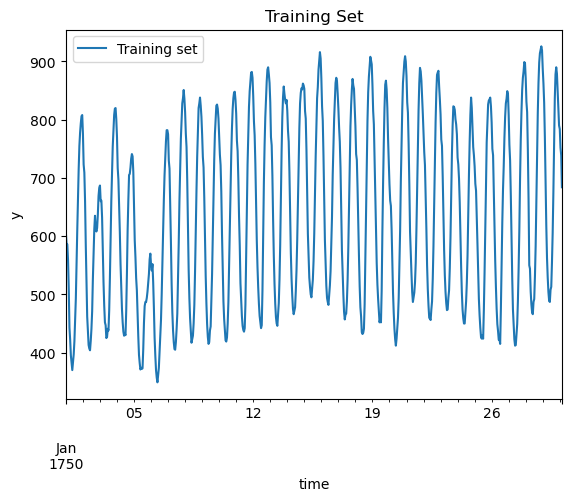

First timestamp: 1750-01-01 00:00
Last timestamp: 1750-01-30 03:00


In [111]:
# create an itereator for the training set
train_set_iterator = next(iter(dataset.train))

# convert training set into a pandas series
train_series = to_pandas(train_set_iterator)

# plot training set
train_series.plot()
plt.title('Training Set')
plt.xlabel('time')
plt.ylabel('y')
plt.legend(["Training set"], loc="upper left")
plt.show()

print("First timestamp:", train_series.index[0])  
print("Last timestamp:", train_series.index[-1])  

- `dataset.test` - an iterable collection of data elements used for inference
  - The test dataset is an extended version of the train dataset that contains a window in the end of each time series that was not seen during training
  - This window has length equal to the recommended prediction length

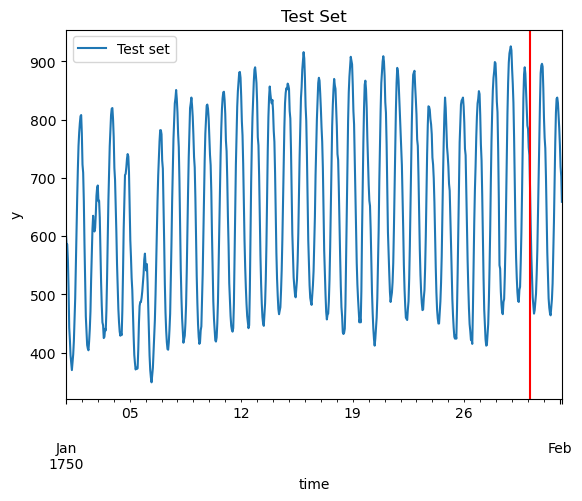

First timestamp: 1750-01-01 00:00
Last timestamp: 1750-02-01 03:00


In [112]:
# create an itereator for the test set
test_set_iterator = next(iter(dataset.test))

# convert test set into a pandas series
test_series = to_pandas(test_set_iterator)

# plot test set and training set
test_series.plot()
plt.axvline(train_series.index[-1], color="r")  # end of training set
plt.title('Test Set')
plt.xlabel('time')
plt.ylabel('y')
plt.legend(["Test set"], loc="upper left")
plt.show()

print("First timestamp:", test_series.index[0])  
print("Last timestamp:", test_series.index[-1])  

- `dataset.metadata` - contains metadata of the dataset such as the frequency of the time series, a recommended prediction horizon, associated features, etc.

In [113]:
forecasting_window_length = len(test_series) - len(train_series)
print(
    f"Length of forecasting window in test dataset: {forecasting_window_length}"
)

prediction_length = dataset.metadata.prediction_length
print(f"Recommended prediction horizon: {prediction_length}")

frequency = dataset.metadata.freq
print(f"Frequency of the time series: {frequency}")

Length of forecasting window in test dataset: 48
Recommended prediction horizon: 48
Frequency of the time series: H


Read [here](https://ts.gluon.ai/stable/tutorials/forecasting/extended_tutorial.html#Datasets) for info on custom datasets

## Model

The [`Estimator`](https://ts.gluon.ai/stable/api/gluonts/gluonts.torch.model.estimator.html?highlight=estimator#module-gluonts.torch.model.estimator) class represents forecasting models. 

Each estimator is configured by a number of hyperparameters e.g. `prediction_length`.

We'll use a DeepAR model ([`DeepAREstimator`](https://ts.gluon.ai/stable/api/gluonts/gluonts.torch.html?highlight=deeparestimator#gluonts.torch.DeepAREstimator)).

Read [here](https://ts.gluon.ai/stable/tutorials/forecasting/extended_tutorial.html#Create-your-own-model) for info on custom models.

In [114]:
# define additional training arguments for pl.Trainer
trainer_kwargs = {  
        "max_epochs": 50,  
    }

estimator = DeepAREstimator(
    freq=frequency,
    prediction_length=prediction_length,
    context_length=100,
    lr=1e-3,
    weight_decay=1e-8,
    num_batches_per_epoch=100,
    trainer_kwargs=trainer_kwargs
)

c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\gluonts\time_feature\_base.py:249: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset = to_offset(freq_str)


### Training

We can train our model by calling the estimator's [`train()`](https://ts.gluon.ai/stable/api/gluonts/gluonts.torch.model.estimator.html#gluonts.torch.model.estimator.PyTorchLightningEstimator.train) method using our training set.

This returns a fitted model (which GluonTS calls a [`Predictor`](https://ts.gluon.ai/stable/api/gluonts/gluonts.model.html#gluonts.model.Predictor)), which can be used for inference.
- Note: In GluonTS, models are trained using PyTorch Lightning's `pl.Trainer` class

In [115]:
predictor = estimator.train(training_data=dataset.train)

c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\gluonts\time_feature\lag.py:104: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset = to_offset(freq_str)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name  | Type        | Params | Mode  | In sizes                                                      | Out sizes   
-----------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 27.6 K | train | [[1, 1], [1, 1], [1, 820, 5], [1, 820], [1, 820], [1, 48, 5]] | [1, 100, 48]
------------------------------------------------------------------------------------------------------------------------

Epoch 0: |          | 100/? [00:12<00:00,  8.24it/s, v_num=12, train_loss=5.040]

Epoch 0, global step 100: 'train_loss' reached 5.03980 (best 5.03980), saving model to 'c:\\Users\\Mike\\vscode\\TEMPO_prob\\gluonts\\lightning_logs\\version_12\\checkpoints\\epoch=0-step=100.ckpt' as top 1


Epoch 1: |          | 100/? [00:10<00:00,  9.41it/s, v_num=12, train_loss=4.550]

Epoch 1, global step 200: 'train_loss' reached 4.55001 (best 4.55001), saving model to 'c:\\Users\\Mike\\vscode\\TEMPO_prob\\gluonts\\lightning_logs\\version_12\\checkpoints\\epoch=1-step=200.ckpt' as top 1


...

Epoch 48, global step 4900: 'train_loss' was not in top 1


Epoch 49: |          | 100/? [00:10<00:00,  9.36it/s, v_num=12, train_loss=3.220]

Epoch 49, global step 5000: 'train_loss' was not in top 1
`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: |          | 100/? [00:10<00:00,  9.35it/s, v_num=12, train_loss=3.220]


c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\gluonts\time_feature\lag.py:104: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset = to_offset(freq_str)


### Inference

Now that we have a `Predictor`, we can compute predictions on the test set and evaluate our model.

We can use GluonTS's [`make_evaluation_predictions()`](https://ts.gluon.ai/stable/api/gluonts/gluonts.evaluation.backtest.html?highlight=make_evaluation_predictions#gluonts.evaluation.backtest.make_evaluation_predictions) function to automate the process of computing test set predictions and model evaluation.
- In GluonTS, sample paths are possible future scenarios (trajectories) generated by a probabilistic forecasting model.
- They show various possibilities for what the test set can look like.

In [116]:
forecast_iterator, time_series_iterator = make_evaluation_predictions(
    dataset=dataset.test,
    predictor=predictor,
    num_samples=100,  # number of sample paths to compute
)

# convert the iterators into lists
forecasts = list(forecast_iterator)
time_series_set = list(time_series_iterator)

- forecasts is a list where each element is a [`SampleForecast`](https://ts.gluon.ai/stable/api/gluonts/gluonts.model.forecast.html?highlight=sampleforecast#gluonts.model.forecast.SampleForecast) object (an abstract class for representing predictions)
- time_series_set is a list where each element is a time series from the test set in the form of a pandas DataFrame

The 0th element of forecasts and time_series_set contains the target values (i.e. the actually observed values) of first time series in the test set.

`time_series_set[0]` is a pandas Series where the index is a timestamp and the values are the time series's observed values.

In [117]:
# get the first time series in the test set
first_time_series = time_series_set[0]

# get the first 5 values of the first time series
np.array(first_time_series[:5]).reshape(-1,)

array([605., 586., 586., 559., 511.], dtype=float32)

Notice how `time_series_set[0]` has the same values as the first entry of `dataset.test`
- `time_series_set[0]` is a pandas Series where the indices are timestamps and the values are the observed time series's values
-  `first entry` is a dictionary where the keys are timestamps and the values are the observed time series's values

In [118]:
first_time_series_entry = next(iter(dataset.test))
first_time_series_entry["target"][:5]

array([605., 586., 586., 559., 511.], dtype=float32)

The $i^{\text{th}}$ element of `forecasts` is a [`SampleForecast`](https://ts.gluon.ai/stable/api/gluonts/gluonts.model.forecast.html?highlight=sampleforecast#gluonts.model.forecast.SampleForecast) object.

It contains all the samples paths for the $i^{\text{th}}$ time series in a `numpy.ndarray` of shape `(num_samples, prediction_length)`.

Each `SampleForecast` object also contains metadata e.g. the forecast's start date.

In [119]:
# first entry of forecasts
first_forecast_entry = forecasts[0]

print(f"Number of sample paths: {first_forecast_entry.num_samples}")
print(f"Dimension of samples: {first_forecast_entry.samples.shape}")
print(f"Start date of the forecast window: {first_forecast_entry.start_date}")
print(f"Frequency of the time series: {first_forecast_entry.freq}")

Number of sample paths: 100
Dimension of samples: (100, 48)
Start date of the forecast window: 1750-01-30 04:00
Frequency of the time series: <Hour>


Since we have a distribution of samples at each future time step, we can also perform calculations on the sample paths e.g. computing the mean or quantile

In [120]:
print(f"Mean of the future window:\n {first_forecast_entry.mean}")
print(f"0.5-quantile (median) of the future window:\n {first_forecast_entry.quantile(0.5)}")

Mean of the future window:
 [627.83374 570.0662  535.56177 511.9893  500.09686 497.78363 503.66058
 527.7661  548.1067  588.78705 650.11566 721.2813  794.171   843.2193
 872.37354 874.4459  874.4691  855.7324  836.53937 797.8579  766.12134
 733.4026  722.68756 677.7907  622.4636  567.7548  533.618   513.0572
 503.70764 495.68747 509.24442 533.73315 559.50116 607.0605  670.15717
 748.94836 816.15155 873.4324  896.9755  908.6344  899.1531  876.1635
 853.03595 822.96454 784.94727 735.7851  711.1951  654.6708 ]
0.5-quantile (median) of the future window:
 [629.9315  567.1055  537.14844 511.45242 495.72705 494.44568 504.9924
 524.7091  545.68555 588.82336 648.1181  724.1005  800.15466 844.05176
 873.4053  879.7536  872.25085 854.74225 835.49786 798.2458  764.9018
 736.91016 721.70636 682.17346 623.8208  568.4257  536.59937 516.9347
 503.00766 496.36673 511.40717 530.69934 558.93195 602.9572  670.6617
 745.8344  816.3044  875.84094 898.088   909.38025 897.3779  870.9609
 850.668   820.01807 

`Forecast` objects have a `plot()` method that can be used to visualize the forecast paths

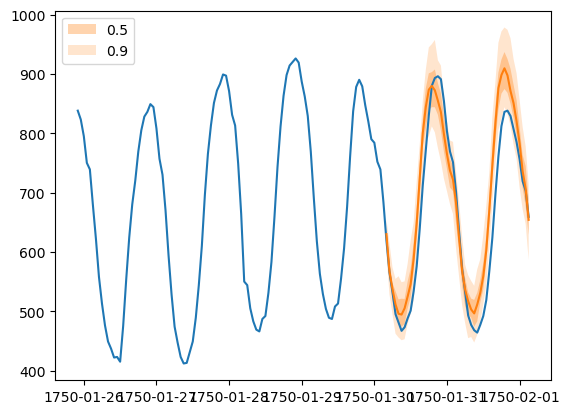

In [121]:
plt.plot(first_time_series[-150:].to_timestamp())
first_forecast_entry.plot(show_label=True)
plt.legend()

### Evaluation

The [`Evaluator`](https://ts.gluon.ai/stable/api/gluonts/gluonts.evaluation.html?highlight=evaluator#gluonts.evaluation.Evaluator) class can be used to evaluate our model

In [122]:
evaluator = Evaluator(quantiles=[0.1, 0.5, 0.9])
aggregated_metrics, item_metrics = evaluator(time_series_set, forecasts)

Running evaluation: 414it [00:01, 313.01it/s]


- `aggregated_metrics` is a dictionary containing metrics aggregated across time steps and time series
  - These metrics evaluate the overall forecast quality across all time series

In [123]:
print(json.dumps(aggregated_metrics, indent=4))

{
    "MSE": 4652228.6607375555,
    "abs_error": 7592823.356674194,
    "abs_target_sum": 145558863.59960938,
    "abs_target_mean": 7324.822041043146,
    "seasonal_error": 336.9046924038305,
    "MASE": 2.0276070174353245,
    "MAPE": 0.1283207878023506,
    "sMAPE": 0.11181850631641833,
    "MSIS": 18.666143870314254,
    "num_masked_target_values": 0.0,
    "QuantileLoss[0.1]": 4617301.914463902,
    "Coverage[0.1]": 0.12510064412238325,
    "QuantileLoss[0.5]": 7592823.364211082,
    "Coverage[0.5]": 0.4324677938808374,
    "QuantileLoss[0.9]": 3340493.352084922,
    "Coverage[0.9]": 0.8696658615136876,
    "RMSE": 2156.9025617161187,
    "NRMSE": 0.2944648415525122,
    "ND": 0.052163249759629,
    "wQuantileLoss[0.1]": 0.031721200621384164,
    "wQuantileLoss[0.5]": 0.05216324981140797,
    "wQuantileLoss[0.9]": 0.022949432755078797,
    "mean_absolute_QuantileLoss": 5183539.543586635,
    "mean_wQuantileLoss": 0.03561129439595698,
    "MAE_Coverage": 0.3898886205045626,
    "O

- `item_metrics` is a pandas DataFrame containing per-series metrics
  - Each row corresponds to a single time series

In [124]:
item_metrics.head()

,item_id,forecast_start,MSE,abs_error,abs_target_sum,abs_target_mean,seasonal_error,MASE,MAPE,sMAPE,num_masked_target_values,ND,MSIS,QuantileLoss[0.1],Coverage[0.1],QuantileLoss[0.5],Coverage[0.5],QuantileLoss[0.9],Coverage[0.9]
0,0,1750-01-30 04:00,2987.768555,2098.822266,31644.0,659.250000,42.371302,1.031959,0.067971,0.064951,0.0,0.066326,6.275180,1163.937427,0.354167,2098.822266,0.750000,766.395349,0.958333
1,1,1750-01-30 04:00,216629.500000,20842.068359,124149.0,2586.437500,165.107988,2.629853,0.178756,0.161200,0.0,0.167879,40.648809,21938.413306,0.979167,20842.069336,1.000000,5831.887061,1.000000
2,2,1750-01-30 04:00,29543.265625,5779.496094,65030.0,1354.791667,78.889053,1.526272,0.074501,0.080127,0.0,0.088874,24.052989,1831.733716,0.000000,5779.495972,0.270833,6165.582715,0.562500
3,3,1750-01-30 04:00,94589.312500,11074.310547,235783.0,4912.145833,258.982249,0.890852,0.047303,0.046228,0.0,0.046968,7.190702,5655.830322,0.125000,11074.310059,0.645833,4689.292725,0.895833
4,4,1750-01-30 04:00,30685.091146,6213.909668,131088.0,2731.000000,200.494083,0.645687,0.045834,0.045609,0.0,0.047403,4.299126,3186.812573,0.104167,6213.909546,0.520833,3184.573535,0.916667
